In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
SEED = 42

# Data

In [3]:
file_path = './data/raw/TOI_2026.07.23_10.15.02.csv'

raw = pd.read_csv(file_path,skiprows=30)
print(raw.shape)
raw

(8064, 27)


,rowid,toi,toipfx,tid,ctoi_alias,pl_pnum,tfopwg_disp,rastr,ra,decstr,...,pl_rade,pl_insol,pl_eqt,st_tmag,st_dist,st_teff,st_logg,st_rad,toi_created,rowupdate
0,1,1000.01,1000,50365310,5.036531e+07,1,FP,07h29m25.85s,112.357708,-12d41m45.46s,...,5.818163,22601.948581,3127.204052,9.604000,485.735,10249.0,4.19,2.169860,2019-07-24 15:58:33,2024-09-09 10:08:01
1,2,1001.01,1001,88863718,8.886372e+07,1,PC,08h10m19.31s,122.580465,-05d30m49.87s,...,11.215400,44464.500000,4045.000000,9.423440,295.862,7070.0,4.03,2.010000,2019-07-24 15:58:33,2023-04-03 14:31:04
2,3,1002.01,1002,124709665,1.247097e+08,1,FP,06h58m54.47s,104.726966,-10d34m49.64s,...,23.752900,2860.610000,2037.000000,9.299501,943.109,8924.0,NaN,5.730000,2019-07-24 15:58:33,2022-07-11 16:02:02
3,4,1003.01,1003,106997505,1.069975e+08,1,FP,07h22m14.39s,110.559945,-25d12m25.26s,...,NaN,1177.360000,1631.000000,9.300300,7728.170,5388.5,4.15,NaN,2019-07-24 15:58:33,2022-02-23 10:10:02
4,5,1004.01,1004,238597883,2.385979e+08,1,FP,08h08m42.77s,122.178195,-48d48m10.12s,...,11.311300,54679.300000,4260.000000,9.135500,356.437,9219.0,4.14,2.150000,2019-07-24 15:58:33,2024-09-09 10:08:01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,8060,995.01,995,317951248,3.179512e+08,1,FP,07h23m14.75s,110.811443,+05d33m46.26s,...,NaN,1413.670000,1708.000000,10.078100,1080.880,4805.2,NaN,NaN,2019-07-24 15:58:33,2021-10-29 12:59:15
8060,8061,996.01,996,142918609,1.429186e+08,1,FP,07h57m23.99s,119.349948,-19d30m57.65s,...,16.052300,NaN,NaN,9.792500,379.693,8007.0,NaN,2.050000,2019-07-24 15:58:33,2021-10-29 12:59:15
8061,8062,997.01,997,341729521,3.417295e+08,1,FP,08h05m16.69s,121.319521,-59d34m47.27s,...,20.510696,127.916421,857.731431,9.772700,113.667,5786.0,4.52,0.926261,2019-07-24 15:58:33,2024-09-09 10:08:01
8062,8063,998.01,998,54390047,5.439005e+07,1,FP,07h53m16.69s,118.319555,-14d13m07.76s,...,4.529209,41562.587811,3641.626449,9.695200,482.278,8322.0,4.01,2.349860,2019-07-24 15:58:33,2024-09-09 10:08:01


### Data cleaning

In [4]:
df = raw.drop(['rowid','toi','toipfx','tid','ctoi_alias','pl_pnum','rastr','decstr','toi_created','rowupdate'],axis=1)

# Since RA and declination are cyclic, convert them into their sin() and cos() values to ensure cyclic behaviour
df.insert(0,'cos_dec',np.cos(np.radians(df['dec'])))
df.insert(0,'sin_dec',np.sin(np.radians(df['dec'])))
df.insert(0,'cos_ra',np.cos(np.radians(df['ra'])))
df.insert(0,'sin_ra',np.sin(np.radians(df['ra'])))

df = df.drop(['ra','dec'],axis=1)

# Drop rows with missing disposition (target) value
df['disp'] = df.pop('tfopwg_disp')
df = df.dropna(subset=['disp'])
# Group dispositions into three groups

disp_map = {'APC':'PC',
            'FA':'F',
            'FP':'F',
            'KP':'C',
            'PC':'PC',
            'CP':'C'}
df['disp'] = df['disp'].map(disp_map)
df

,sin_ra,cos_ra,sin_dec,cos_dec,st_pmra,st_pmdec,pl_tranmid,pl_orbper,pl_trandurh,pl_trandep,pl_rade,pl_insol,pl_eqt,st_tmag,st_dist,st_teff,st_logg,st_rad,disp
0,0.924827,-0.380388,-0.219777,0.975550,-5.964,-0.076,2.459230e+06,2.171348,2.017220,656.886099,5.818163,22601.948581,3127.204052,9.604000,485.735,10249.0,4.19,2.169860,F
1,0.842636,-0.538484,-0.096086,0.995373,-4.956,-15.555,2.459988e+06,1.931646,3.166000,1286.000000,11.215400,44464.500000,4045.000000,9.423440,295.862,7070.0,4.03,2.010000,PC
2,0.967148,-0.254213,-0.183616,0.982998,-1.462,-2.249,2.459225e+06,1.867557,1.408000,1500.000000,23.752900,2860.610000,2037.000000,9.299501,943.109,8924.0,NaN,5.730000,F
3,0.936305,-0.351187,-0.425890,0.904775,-0.939,1.640,2.458493e+06,2.743230,3.167000,383.410000,NaN,1177.360000,1631.000000,9.300300,7728.170,5388.5,4.15,NaN,F
4,0.846396,-0.532554,-0.752447,0.658653,-4.496,9.347,2.459987e+06,3.573014,3.370000,755.000000,11.311300,54679.300000,4260.000000,9.135500,356.437,9219.0,4.14,2.150000,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,0.934755,-0.355294,0.096938,0.995290,2.061,-7.082,2.458494e+06,3.443800,2.572000,7260.750000,NaN,1413.670000,1708.000000,10.078100,1080.880,4805.2,NaN,NaN,F
8060,0.871642,-0.490142,-0.334070,0.942548,-3.900,3.866,2.458495e+06,14.537800,6.826000,4040.000000,16.052300,NaN,NaN,9.792500,379.693,8007.0,NaN,2.050000,F
8061,0.854282,-0.519810,-0.862335,0.506338,-44.770,-2.616,2.459230e+06,8.413486,3.556833,17479.605331,20.510696,127.916421,857.731431,9.772700,113.667,5786.0,4.52,0.926261,F
8062,0.880315,-0.474389,-0.245626,0.969365,-1.706,-1.714,2.459230e+06,0.941436,1.360700,339.912662,4.529209,41562.587811,3641.626449,9.695200,482.278,8322.0,4.01,2.349860,F


### EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8061 entries, 0 to 8063
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sin_ra       8061 non-null   float64
 1   cos_ra       8061 non-null   float64
 2   sin_dec      8061 non-null   float64
 3   cos_dec      8061 non-null   float64
 4   st_pmra      7926 non-null   float64
 5   st_pmdec     7926 non-null   float64
 6   pl_tranmid   8061 non-null   float64
 7   pl_orbper    7955 non-null   float64
 8   pl_trandurh  8057 non-null   float64
 9   pl_trandep   8061 non-null   float64
 10  pl_rade      7541 non-null   float64
 11  pl_insol     7875 non-null   float64
 12  pl_eqt       7740 non-null   float64
 13  st_tmag      8061 non-null   float64
 14  st_dist      7839 non-null   float64
 15  st_teff      7888 non-null   float64
 16  st_logg      7164 non-null   float64
 17  st_rad       7437 non-null   float64
 18  disp         8061 non-null   object 
dtypes: float64(

In [6]:
df.describe()

,sin_ra,cos_ra,sin_dec,cos_dec,st_pmra,st_pmdec,pl_tranmid,pl_orbper,pl_trandurh,pl_trandep,pl_rade,pl_insol,pl_eqt,st_tmag,st_dist,st_teff,st_logg,st_rad
count,8061.000000,8061.000000,8061.000000,8061.000000,7926.000000,7926.000000,8.061000e+03,7955.000000,8057.000000,8061.000000,7541.000000,7875.000000,7740.000000,8061.000000,7839.000000,7888.000000,7164.000000,7437.000000
mean,0.091737,0.011522,0.002930,0.692709,-0.690570,-8.929967,2.459623e+06,17.522089,3.073713,8213.402409,10.306850,2310.407924,1297.079151,11.591789,481.151543,5792.636264,4.304128,1.403028
std,0.737457,0.669128,0.679629,0.241485,75.494071,65.539266,6.633124e+02,96.497983,1.874546,16946.785393,8.406753,11020.849999,693.898853,1.621524,550.603974,1467.098832,0.303398,1.575744
min,-1.000000,-1.000000,-0.999957,0.009224,-1624.050000,-1230.620000,2.457926e+06,0.152076,0.101000,24.583493,0.552507,0.000342,37.000000,4.627800,6.531270,2808.000000,0.100000,0.114827
25%,-0.682562,-0.610149,-0.684266,0.513393,-10.555750,-14.587250,2.459217e+06,2.510638,1.848351,1469.000000,4.561303,88.197107,825.000000,10.422300,181.710500,5216.000000,4.120000,0.890000
50%,0.202668,0.012820,0.030991,0.732884,-1.643000,-3.408000,2.459655e+06,4.127728,2.748000,4750.000000,10.513588,377.954000,1193.500000,11.879500,370.570000,5801.100000,4.330000,1.238240
75%,0.847730,0.639844,0.676965,0.911243,8.023750,4.931500,2.460057e+06,8.088740,3.826952,10338.219281,13.949000,1214.984780,1604.250000,12.869600,652.103500,6297.000000,4.500000,1.661650
max,1.000000,0.999999,0.999873,1.000000,2074.520000,1048.840000,2.461104e+06,1837.889731,30.015619,767910.313098,297.111726,280833.000000,6413.000000,18.808600,14728.300000,50000.000000,5.960650,102.030000


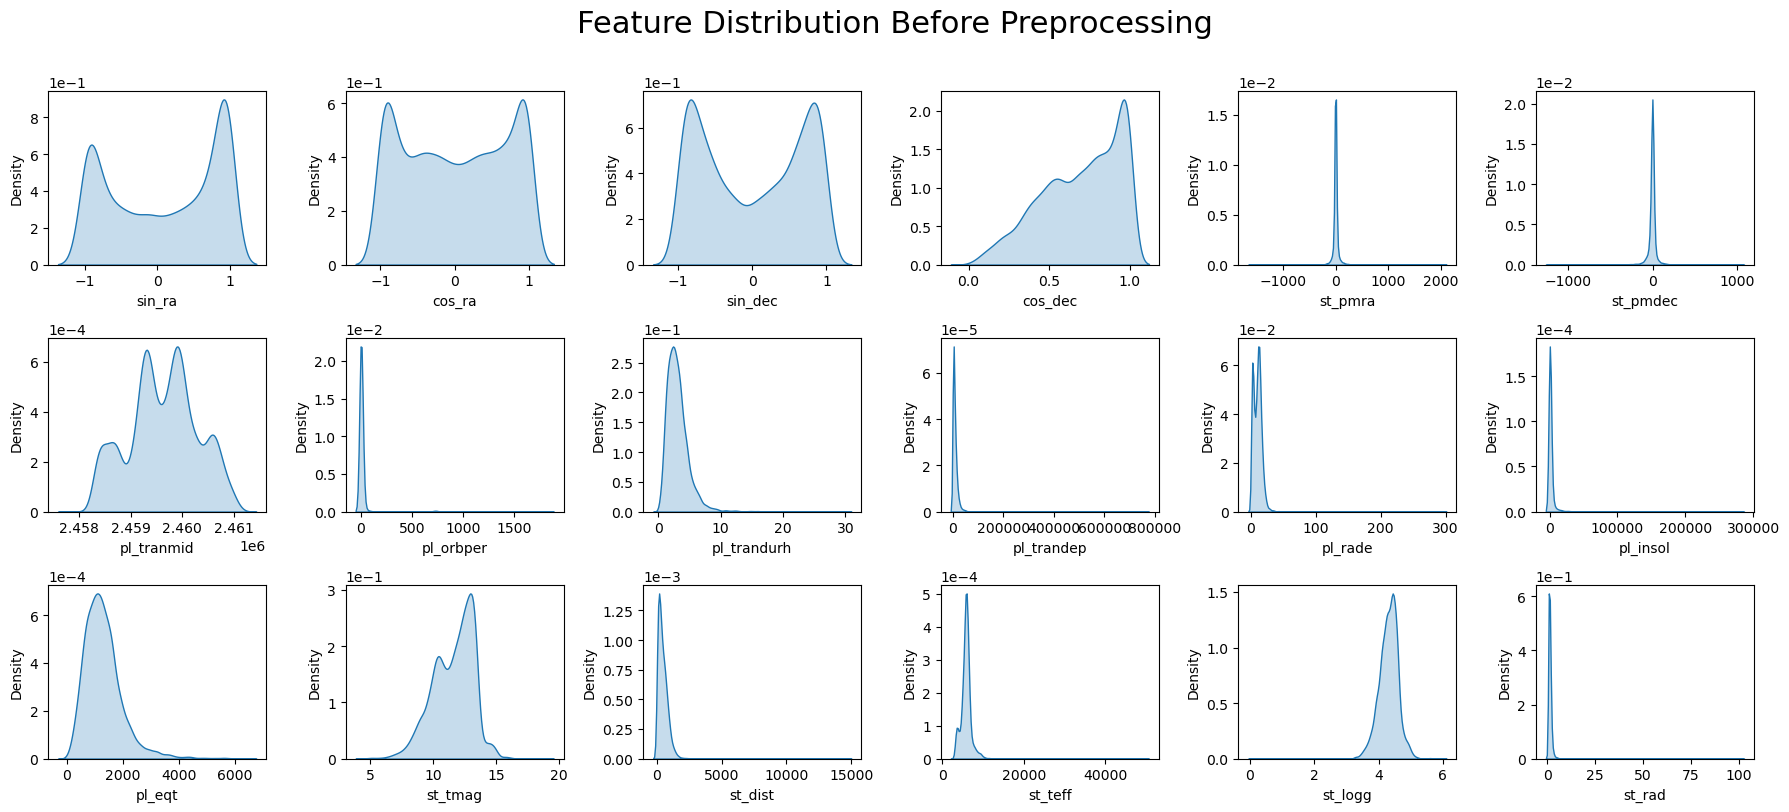

In [7]:
feat_cols = df.columns[:-1]

plt.figure(figsize=(18,8))
for i,col in enumerate(feat_cols):
    plt.subplot(3,6,i+1)
    sns.kdeplot(df,x=col,fill=True)
    plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
plt.suptitle('Feature Distribution Before Preprocessing',fontsize=22,y=1.01)
plt.tight_layout()
plt.show()

<Axes: xlabel='disp', ylabel='count'>

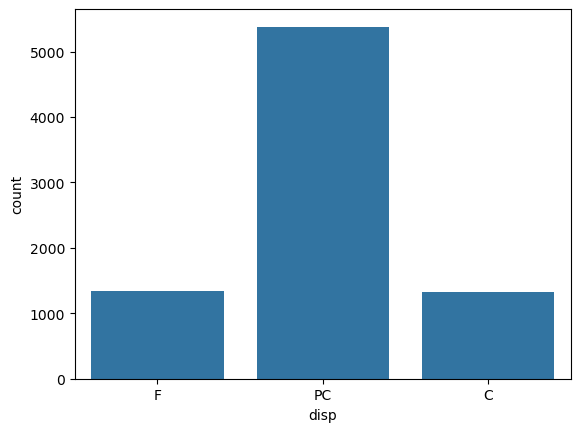

In [8]:
sns.countplot(x=df['disp'])

### Insights
- Most columns are already in numeric datatypes except for `disp`. 
- Some columns have missing values.
- Some columns have extreme outliers.
- Some columns show extreme skewness.

### Preprocessing

In [24]:
from sklearn.base import BaseEstimator,TransformerMixin
import numpy as np
from  dataclasses import dataclass,asdict
import json

class OutlierRemoval(BaseEstimator,TransformerMixin):
    '''
    Outlier removal module.
    '''
    def __init__(self,iqr_boundary:float=1.5,print_detail:bool=False):
        '''
        Initializes outlier removal module using IQR method.
        Note: Order matters! Keep same column order on both train and test set to prevent removal errors.

        Args:
            iqr_boundary (float): IQR boundary value to use
            print_detail (bool): Whether to print count of removed rows or not
        Returns:
            None
        '''
        self.iqr_boundary = iqr_boundary
        self.print_detail = print_detail

        self.state = OutlierRemovalState()

    def fit(self,X_and_y):
        X,y = X_and_y
        X = np.asarray(X,dtype=np.float32)
        median = np.nanmedian(X,axis=0)
        q3 = np.nanpercentile(X,75,axis=0)
        q1 = np.nanpercentile(X,25,axis=0)
        iqr = q3 - q1

        self.lower_ = median - self.iqr_boundary*iqr
        self.upper_ = median + self.iqr_boundary*iqr

        self.state.iqr_boundary = float(self.iqr_boundary)
        self.state.lower_ = [float(low) for low in self.lower_]
        self.state.upper_ = [float(up) for up in self.upper_]

        return self

    def transform(self,X_and_y):
        X,y = X_and_y
        X = np.asarray(X,dtype=np.float32)
        outlier_mask = (X < self.lower_) | (X > self.upper_)
        any_outlier = outlier_mask.any(axis=1)

        X_new = X[~any_outlier]
        y_new = y[~any_outlier]
        if self.print_detail:
            print(f'Removed {any_outlier.sum()} rows during outlier removal')
        return (X_new,y_new)

    def save_state_dict(self,file_path):
        '''
        Saves state dict into a JSON file.

        Args:
            file_path (str): Path where the JSON file will be saved.
        Returns:
            None 
        '''
        self.state.save(file_path=file_path)

    def load_state_dict(self,file_path):
        '''
        Loads a JSON state dict into self.

        Args:
            file_path (str): Path to the JSON file containing the state dict.
        Returns:
            None 
        '''
        self.state.load(file_path=file_path)

@dataclass
class OutlierRemovalState:
    iqr_boundary:float | None = None
    lower_:float | None = None
    upper_:float | None = None

    def save(self,file_path:str) -> None:
        with open(file_path,'w') as file:
            json.dump(asdict(self),file,indent=2)

    def load(self,file_path:str) -> None:
        with open(file_path,'r') as file:
            data = json.load(file)
        self.iqr_boundary = data.get('iqr_boundary')
        self.lower_ = data.get('lower_')
        self.upper_ = data.get('upper_')

In [25]:
from sklearn.model_selection import train_test_split

df_trainval = df[df['disp'] != 'PC']
df_test = df[df['disp'] == 'PC']

X_trainval = df_trainval.drop('disp',axis=1)
y_trainval = df_trainval['disp']

X_train,X_val,y_train,y_val = train_test_split(X_trainval,y_trainval,test_size=0.2,random_state=SEED,stratify=y_trainval)

X_test = df_test.drop('disp',axis=1)
y_test = df_test['disp']

In [26]:
outlier = OutlierRemoval(3,print_detail=False)
X_train_rm,y_train_rm = outlier.fit_transform((X_train,y_train))
X_val_rm,y_val_rm = outlier.transform((X_val,y_val))
X_test_rm,y_test_rm = outlier.transform((X_test,y_test))

y_train_rm,y_val_rm,y_test_rm = y_train_rm.to_numpy(), y_val_rm.to_numpy(), y_test_rm.to_numpy()

print(f'Number of train samples after removing outliers: {X_train_rm.shape[0]}')
print(f'Number of val samples after removing outliers: {X_val_rm.shape[0]}')
print(f'Number of test samples after removing outliers: {X_test_rm.shape[0]}')

Number of train samples after removing outliers: 1291
Number of val samples after removing outliers: 320
Number of test samples after removing outliers: 4114


In [13]:
X_train

,sin_ra,cos_ra,sin_dec,cos_dec,st_pmra,st_pmdec,pl_tranmid,pl_orbper,pl_trandurh,pl_trandep,pl_rade,pl_insol,pl_eqt,st_tmag,st_dist,st_teff,st_logg,st_rad
1282,-0.733492,-0.679698,0.991324,0.131445,35.892,-66.784,2.458820e+06,6.277248,1.532501,910.521554,2.538544,105.278027,816.966378,11.0372,151.1030,5244.00,4.58339,0.800741
6466,0.986538,-0.163532,-0.839499,0.543361,5.936,9.719,2.460974e+06,9.516003,2.274422,527.949401,22.396003,504.139583,1320.096985,10.1032,673.0280,4481.60,NaN,8.180000
5646,-0.713318,0.700841,0.330166,0.943923,-1.735,-1.282,2.459823e+06,6.204375,5.957000,4380.000000,14.954800,911.223000,1530.000000,11.4290,707.0920,6122.00,3.71000,2.490000
4071,-0.442259,0.896887,-0.296555,0.955016,-12.590,-22.096,2.459448e+06,2.849280,2.007216,3881.584429,4.680228,137.927690,874.042629,12.3071,159.5220,4279.00,4.53000,0.740000
5666,-0.675062,0.737761,0.618951,0.785430,-5.906,-5.905,2.459823e+06,1.654080,2.008000,3460.000000,15.214500,2118.230000,1889.000000,11.7528,799.1230,6453.00,3.76000,2.510000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8049,0.929493,-0.368839,0.122152,0.992511,15.610,-6.350,2.458495e+06,8.769050,3.504000,14361.000000,21.008900,538.251000,1341.000000,10.2462,260.6410,5906.80,4.22000,1.590000
6764,0.994770,-0.102143,0.431193,0.902260,-1.146,-7.973,2.460255e+06,3.668810,2.151000,8447.000000,9.859730,265.932000,1125.000000,13.3268,684.5070,5821.50,4.36000,1.120000
99,-0.999186,0.040330,-0.971553,0.236822,-23.549,-45.079,2.458626e+06,1.153950,2.236000,1550.000000,5.483640,3534.300000,2148.000000,10.4613,240.9010,6093.00,4.20000,1.400000
464,-0.281754,0.959487,0.810674,0.585498,-94.070,9.950,2.460610e+06,2.726017,2.703000,1165.000000,4.980360,4788.290000,2317.000000,10.4602,115.7460,5256.00,4.59000,0.790000


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.decomposition import PCA
from src.modules.aslt import ASLT

# Transform
pl_features = Pipeline([
    ('imputer',KNNImputer(n_neighbors=10)),
    ('autolog',ASLT(beta=20)),
    ('scaler',StandardScaler()),
    ('pca',PCA()),
])
pl_target = Pipeline([
    ('encoder',OrdinalEncoder(categories=[['F','C','PC']]))
])

X_train_pr = pl_features.fit_transform(X_train_rm)
X_val_pr = pl_features.transform(X_val_rm)
X_test_pr = pl_features.transform(X_test_rm)

y_train_pr = pl_target.fit_transform(y_train_rm.reshape(-1,1)).flatten()
y_val_pr = pl_target.transform(y_val_rm.reshape(-1,1)).flatten()
y_test_pr = pl_target.transform(y_test_rm.reshape(-1,1)).flatten()

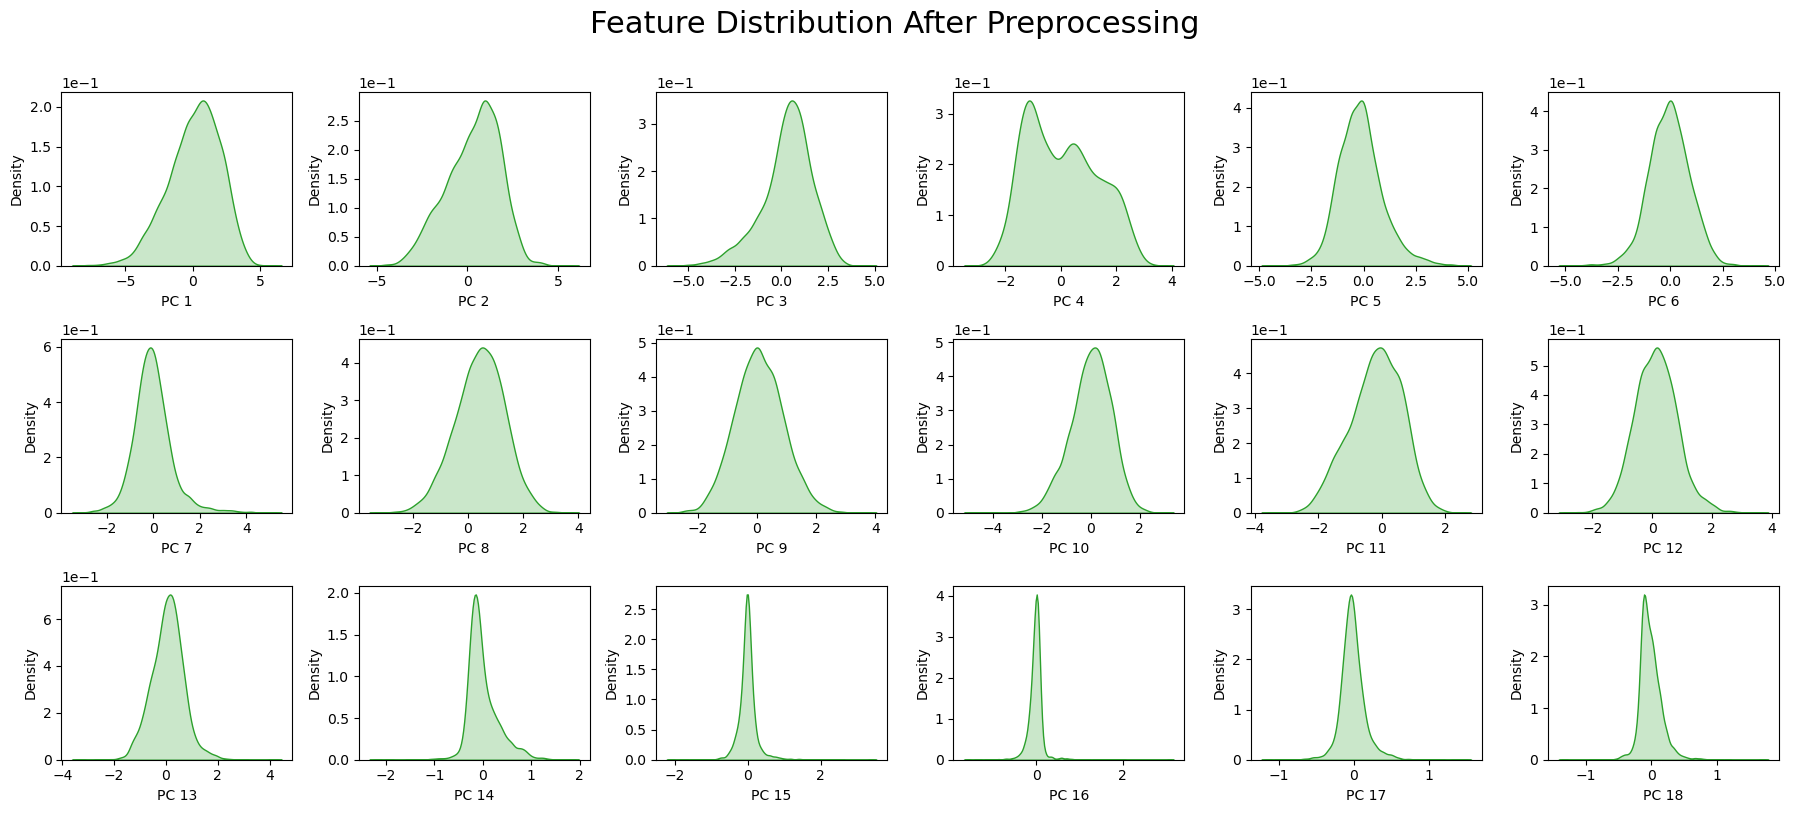

In [21]:
_X_vis_pr = np.vstack([X_train_pr,X_val_pr,X_test_pr])

plt.figure(figsize=(18,8))
for i in range(_X_vis_pr.shape[1]):
    plt.subplot(3,6,i+1)
    sns.kdeplot(x=_X_vis_pr[:,i],fill=True,color='C2')
    plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
    plt.xlabel(f'PC {i+1}')
plt.suptitle('Feature Distribution After Preprocessing',fontsize=22,y=1.01)
plt.tight_layout()
plt.show()

# Modelling

### Hyperparameter Tuning with Optuna

In [22]:
import optuna
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

def objective(trial):
    param_grid = {
        'C': trial.suggest_float('C',1e-2,1e1),
        'kernel': trial.suggest_categorical('kernel',['linear','poly','rbf']),
        'degree': trial.suggest_int('degree',2,4),
    }
    estimator = Pipeline([
        ('preprocessing',pl_features),
        ('model',SVC(gamma='scale',**param_grid))
    ])

    # y uses _pr because it needs to be encoded, X uses _rm because preprocessing happens inside the pipeline
    scores = cross_val_score(estimator,X_train_rm,y_train_pr,cv=5,n_jobs=8,scoring='recall')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=50)

[I 2026-07-26 17:49:14,072] A new study created in memory with name: no-name-697f1bda-4a81-433d-887b-7697e04f6ea5
[I 2026-07-26 17:49:15,747] Trial 0 finished with value: 0.8412213740458017 and parameters: {'C': 3.0599492583547616, 'kernel': 'rbf', 'degree': 2}. Best is trial 0 with value: 0.8412213740458017.
[I 2026-07-26 17:49:16,842] Trial 1 finished with value: 0.851908396946565 and parameters: {'C': 7.716661283217944, 'kernel': 'rbf', 'degree': 3}. Best is trial 1 with value: 0.851908396946565.
[I 2026-07-26 17:49:16,918] Trial 2 finished with value: 0.8488549618320611 and parameters: {'C': 5.019583687788886, 'kernel': 'rbf', 'degree': 4}. Best is trial 1 with value: 0.851908396946565.
[I 2026-07-26 17:49:16,973] Trial 3 finished with value: 0.8549618320610687 and parameters: {'C': 1.7709688862444875, 'kernel': 'rbf', 'degree': 4}. Best is trial 3 with value: 0.8549618320610687.
[I 2026-07-26 17:49:17,119] Trial 4 finished with value: 0.7847328244274809 and parameters: {'C': 4.518

In [24]:
study.best_params

{'C': 1.8056897230247577, 'kernel': 'poly', 'degree': 4}